In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv(r"train.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [10]:
df["Postal Code"]=df["Postal Code"].fillna(df["Postal Code"].mode)

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [12]:
# So now Our Data set is Clean so there is Zero Null values

In [21]:
# Total Sales By region
total_sales=df.groupby("Region")["Sales"].sum().sort_values(ascending=True)

<BarContainer object of 4 artists>

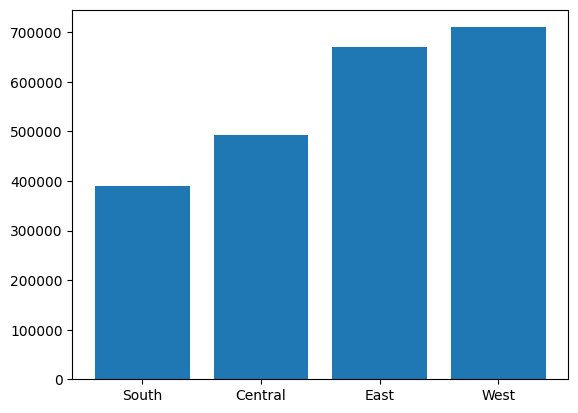

In [26]:
plt.bar(x=total_sales.index,height=top_products.values)

# West region has more sales As compare South

In [35]:
top_product=df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

In [58]:
df["Order Date"]

0       08/11/2017
1       08/11/2017
2       12/06/2017
3       11/10/2016
4       11/10/2016
           ...    
9795    21/05/2017
9796    12/01/2016
9797    12/01/2016
9798    12/01/2016
9799    12/01/2016
Name: Order Date, Length: 9800, dtype: object

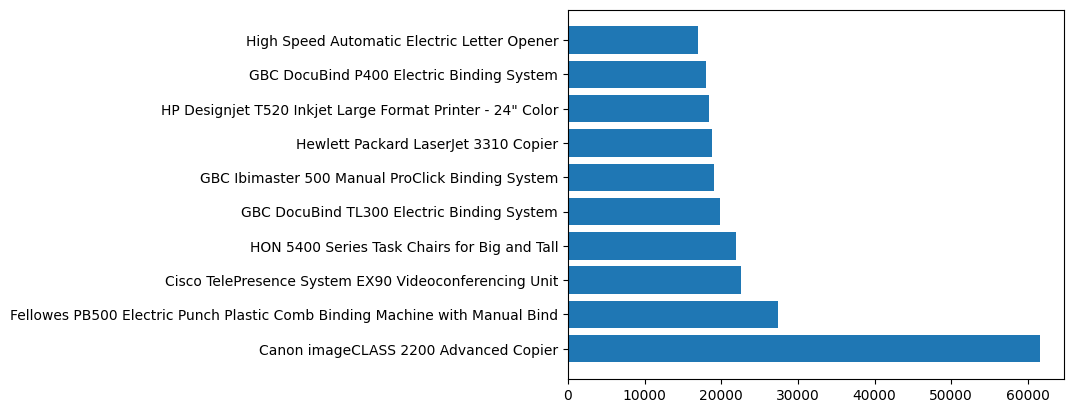

In [50]:
top_product=df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.barh(top_product.index,top_product.values)
plt.show()

In [51]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [61]:
df["Order Date"]=pd.to_datetime(df["Order Date"],format='%d/%m/%Y')

In [63]:
df["Month"]=df["Order Date"].dt.to_period("m")

C:\Users\rohit\AppData\Local\Temp\ipykernel_19184\3740887286.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'M' instead.
  df["Month"]=df["Order Date"].dt.to_period("m")


In [65]:
monthly_sales=df.groupby("Month")["Sales"].sum()

In [69]:
monthly_sales=monthly_sales.to_timestamp()

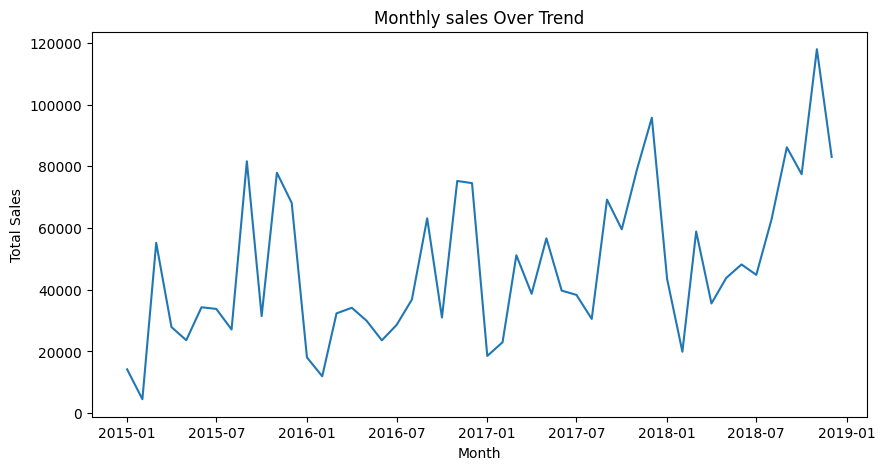

In [75]:
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index,y=monthly_sales.values)
plt.ylabel("Total Sales")
plt.title("Monthly sales Over Trend")
plt.show()

In [76]:
df["Category"]

0             Furniture
1             Furniture
2       Office Supplies
3             Furniture
4       Office Supplies
             ...       
9795    Office Supplies
9796    Office Supplies
9797         Technology
9798         Technology
9799         Technology
Name: Category, Length: 9800, dtype: object

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   object        
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [80]:
total_sales=df.groupby("Region")["Sales"].sum()

<BarContainer object of 4 artists>

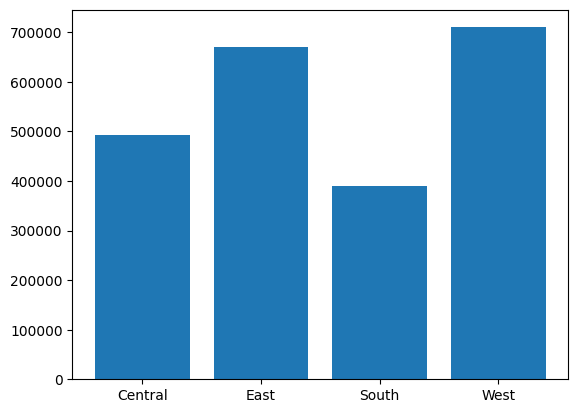

In [83]:
plt.figure()
plt.bar(total_sales.index,total_sales.values)